In [138]:
"""
l1 = [True, True, False, True, True, False, True]
l2 = [True, True, False, True, True, True, False]
l3 = [True, True, False, True, False, True, True]
l4 = [True, True, True, False, False, False, False]
"""
# maksymalizujemy pewną decyzję
def count_certain_elements(all_lists, t = 1):
    count_certain_elements = 0
    for a in range(len(all_lists[0])):
        t_help = 0
        b = 0
        while t_help < t and b < len(all_lists):
            if all_lists[b][a]:
                t_help += 1
            b = b + 1
        if t_help >= t:
            count_certain_elements += 1
    #print("cc=" + str(count_certain_elements))
    return (count_certain_elements / len(all_lists[0]))

def all_subsets(lst):
    if not lst:
        return [[]]
    first = lst[0]
    rest = lst[1:]
    
    subsets_without = all_subsets(rest)
    subsets_with = [[first] + s for s in subsets_without]
    
    return subsets_without + subsets_with

def find_best_solution(lst):
    all_sub = all_subsets(lst)
    max_value = 0
    best_solution = all_sub[0]
    eps = 0.0001
    for ss in all_sub:
        if len(ss) > 0:
            tt = int(len(ss) / 2) + 1
            s_ = count_certain_elements(ss, tt)
            if s_ > max_value and math.fabs(s_ - max_value) > eps:
                max_value = s_
                best_solution = ss
                print(str(len(ss)) + "; " + str(tt) + "; " + str(s_))
    return best_solution

def all_subset_indices(n, start=0):
    """
    n = długość listy
    zwraca wszystkie podzbiory indeksów od 0 do n-1
    """
    if start == n:
        return [[]]
    
    # podzbiory indeksów dla dalszej części listy
    subsets_rest = all_subset_indices(n, start + 1)
    
    # podzbiory, do których dodajemy bieżący indeks 'start'
    subsets_with = [[start] + s for s in subsets_rest]
    
    return subsets_rest + subsets_with



def find_best_solution2(lst):
    all_sub = all_subset_indices(len(lst))
    max_value = 0
    best_solution = all_sub[0]
    eps = 0.0001
    for ss in all_sub:
        if len(ss) > 0:
            tt = int(len(ss) / 2) + 1
            subset = [lst[i] for i in ss]
            s_ = count_certain_elements(subset, tt)
            if s_ > max_value and math.fabs(s_ - max_value) > eps:
                max_value = s_
                best_solution = ss
                print(str(len(ss)) + "; " + str(tt) + "; " + str(s_))
    return best_solution
    

In [144]:
import pickle
import numpy as np
import os

files = os.listdir("numpy_embedding_test")
all_ok_guess = []
for f in files:
    with open("numpy_embedding_test/" + f, "rb") as f:
        all_ok_guess.append(pickle.load(f))


In [151]:
for a in range(len(all_ok_guess)):
    print(files[a] + " " + str(count_certain_elements([all_ok_guess[a]],0.5)))

model_sbert_TH_78000k_.pkl 0.9889855514855515
model_sbert_TH_78000k_gpu1_.pkl 0.8129197191697192
model_sbert_TH_78000k_materialsbert_.pkl 0.9605527574277575
model_sbert_TH_78000k_physbert_.pkl 0.9868551587301587
model_sbert_TH_78000k_scinewsbert_.pkl 0.9863654863654864


In [142]:
res = find_best_solution2(all_ok_guess)


1; 1; 0.9863654863654864
1; 1; 0.9868551587301587
3; 2; 0.9884958791208791
1; 1; 0.9889855514855515
3; 2; 0.9933671652421653


In [143]:
res

[0, 3, 4]

In [140]:
len(res)

3

In [124]:
import math
my_list = [l1, l2, l3, l4]
all_sub = all_subsets(my_list)
max_value = 0
best_solution = all_sub[0]
eps = 0.0001
for ss in all_sub:
    if len(ss) > 0:
        tt = int(len(ss) / 2) + 1
        s_ = count_certain_elements(ss, tt)
        if s_ > max_value and math.fabs(s_ - max_value) > eps:
            max_value = s_
            best_solution = ss
            print(str(len(ss)) + "; " + str(tt) + "; " + str(s_))
print(best_solution)

1; 1; 0.42857142857142855
1; 1; 0.7142857142857143
3; 2; 0.8571428571428571
[[True, True, False, True, True, False, True], [True, True, False, True, True, True, False], [True, True, False, True, False, True, True]]


In [62]:
import pickle
import numpy as np
import os

files = os.listdir("numpy_embedding_test")
all_ok_guess = []
for f in files:
    with open("numpy_embedding_test/" + f, "rb") as f:
        all_ok_guess.append(pickle.load(f))

In [64]:
def calc_diff_indices(l1, l2):
    diff_indices = [i for i, (a, b) in enumerate(zip(l1, l2)) if a != b]
    return diff_indices


In [67]:
diff_numpy = np.zeros((len(all_ok_guess), len(all_ok_guess)))
for a in range(len(all_ok_guess)):
    for b in range(len(all_ok_guess)):
        res_diff_list = calc_diff_indices(all_ok_guess[a], all_ok_guess[b])
        diff_numpy[a,b] = len(res_diff_list) / len(all_ok_guess[a])


In [68]:
diff_numpy

array([[0.        , 0.18456197, 0.04235984, 0.01965685, 0.01746286],
       [0.18456197, 0.        , 0.18806598, 0.18496261, 0.18533781],
       [0.04235984, 0.18806598, 0.        , 0.04433761, 0.03853149],
       [0.01965685, 0.18496261, 0.04433761, 0.        , 0.01940247],
       [0.01746286, 0.18533781, 0.03853149, 0.01940247, 0.        ]])

In [37]:
import pickle
from tqdm import tqdm
import torch
"""
model_sbert_TH_78000k_c_emb.pkl                model_sbert_TH_78000k_physbert_c_emb.pkl
model_sbert_TH_78000k_gpu1_c_emb.pkl           model_sbert_TH_78000k_physbert_q_emb.pkl
model_sbert_TH_78000k_gpu1_q_emb.pkl           model_sbert_TH_78000k_q_emb.pkl
model_sbert_TH_78000k_materialsbert_c_emb.pkl  model_sbert_TH_78000k_scinewsbert_c_emb.pkl.filepart
model_sbert_TH_78000k_materialsbert_q_emb.pkl  model_sbert_TH_78000k_scinewsbert_q_emb.pkl
"""
models_path = ['model_sbert_TH_78000k_',
'model_sbert_TH_78000k_gpu1_',
'model_sbert_TH_78000k_physbert_',
'model_sbert_TH_78000k_scinewsbert_',
'model_sbert_TH_78000k_materialsbert_',
'matscibert_base_',
'all-mpnet-base-v2_base_',
'MaterialsBERT_base_',
'physbert_cased_base_',
'SciNewsBERT_'
]
path_to_dir = '/home/shared_bert/protection/embedding_test/'
id_help = 6
cc = None
qq = None
with open(path_to_dir + models_path[id_help] + "c_emb.pkl", "rb") as f:
    cc = pickle.load(f)
with open(path_to_dir + models_path[id_help] + "q_emb.pkl", "rb") as f:
    qq = pickle.load(f)
# TEST DATASET
    
# 0.9889855514855515
# 0.8129197191697192
# 0.9868551587301587
# 0.9863654863654864
# 0.9605527574277575

# ALL 5 -> 0.9939776658526659

# 0.9254553317053317
# 0.9861301892551892
# 0.797975172975173
# 0.7389982702482703
# 0.8199595543345544

# ALL 5 -> 0.9671919515669516

# OPTIMAL
# 0.9948743386243386
# [0, 2, 3, 5, 7]


# TRAIN DATASET

# 0.9605458455545144
# 0.5721405271611466 -> probably catastrophic forgetting
# 0.9523767332340045
# 0.947079037313528
# 0.8731246482497189

# 0.8122557240491578
# 0.9488610024652644
# 0.631359326113799
# 0.5513105311730491
# 0.6531405540961808


# OPTIMAL
# 0.9728069566104953
# [0, 3, 5]


In [30]:
from typing import List, Dict
import json

# =========================
# DATA LOADING
# =========================

def load_documents_from_json(path: str):
    print(f"Loading data from: {path}")

    with open(path, "r", encoding="utf-8") as f:
        documents = json.load(f)

    print(f"Loaded {len(documents)} papers")
    return documents


def chunk_text(text, chunk_size=300):
    words = text.split()
    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]


def build_documents(papers):
    """
    Tworzy dataset (abstract, chunk)
    """
    documents = []
    id_help = 0
    for p in papers:
        abstract = p.get("abstract", "").strip()
        body = p.get("body", "").strip()

        if not abstract or not body:
            continue

        chunks = chunk_text(body)

        for c in chunks:
            documents.append({
                "abstract_id": id_help,
                "abstract": abstract,
                "chunk": c
            })
        id_help = id_help + 1

    print(f"Generated {len(documents)} (abstract, chunk) pairs")
    return documents


def prepare_data(documents: List[Dict]):
    abstracts_ids = [d["abstract_id"] for d in documents]
    queries = [d["abstract"] for d in documents]
    corpus = [d["chunk"] for d in documents]
    return abstracts_ids, queries, corpus

In [5]:
data_path = "./data/protective_papers_dataset_78000_clean_test.json"
papers = load_documents_from_json(data_path)
documents = build_documents(papers)
abstracts_ids, queries, corpus = prepare_data(documents)

Loading data from: ./data/protective_papers_dataset_78000_clean_test.json
Loaded 7800 papers
Generated 157248 (abstract, chunk) pairs


In [111]:
duplicates = []
uniqe_id = 0
duplicates.append(uniqe_id)
epsilon = 0.0001
for i in tqdm(range(1, qq.shape[0])):
    #if not torch.equal(qq[i-1],qq[i]):
    if torch.dist(qq[i-1],qq[i]) > epsilon:
        uniqe_id += 1
    duplicates.append(uniqe_id)

100%|██████████| 157247/157247 [01:40<00:00, 1569.89it/s]


In [119]:
#duplicates[10] = 55

In [120]:
abstracts_ids == duplicates

False

In [106]:
torch.dist(qq[50],qq[101])

tensor(18.0473, device='cuda:1')

In [3]:
from sentence_transformers import SentenceTransformer, util
import torch
from tqdm import tqdm
# =========================
# METRICS
# =========================

def evaluate_metrics_duplicates(query_embeddings, corpus_embeddings, duplicates, k_values=[5, 10]):
    hits = 0
    mrr = 0
    recall = {k: 0 for k in k_values}

    for i in tqdm(range(len(query_embeddings))):
        scores = util.cos_sim(query_embeddings[i], corpus_embeddings)[0]
        ranked = torch.argsort(scores, descending=True)

        smallest_id_ranked = duplicates[ranked[0].item()]
        smallest_id_i = duplicates[i]
        #print(str(ranked[0].item()) + "; " + str(smallest_id_ranked) + "; " + str(i) + "; " + str(smallest_id_i))

        if smallest_id_ranked == smallest_id_i:
            hits += 1
        # Top-1
        """
        if ranked[0].item() == i:
            hits += 1
        """
        """
        # MRR
        rank = (ranked == i).nonzero(as_tuple=True)[0].item() + 1
        mrr += 1.0 / rank

        # Recall@k
        for k in k_values:
            if i in ranked[:k]:
                recall[k] += 1
        """
    n = len(query_embeddings)
    results = {
        "top1": hits / n
    }
    """
    results = {
        "top1": hits / n,
        "mrr": mrr / n
    }
    
    for k in k_values:
        results[f"recall@{k}"] = recall[k] / n
    """
    return results

/home/thachaj/.torch2_bert/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
evaluate_metrics_duplicates(qq, cc, abstracts_ids, k_values=[5, 10])


100%|██████████| 157248/157248 [12:33<00:00, 208.74it/s]


{'top1': 0.9861301892551892}

In [127]:
abstracts_ids

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,


In [11]:
from sentence_transformers import SentenceTransformer, util
import torch
from tqdm import tqdm
# =========================
# METRICS
# =========================

def evaluate_metrics(query_embeddings, corpus_embeddings, k_values=[5, 10]):
    hits = 0
    mrr = 0
    recall = {k: 0 for k in k_values}

    for i in tqdm(range(len(query_embeddings))):
        scores = util.cos_sim(query_embeddings[i], corpus_embeddings)[0]
        ranked = torch.argsort(scores, descending=True)

        # Top-1
        if ranked[0].item() == i:
            hits += 1

        # MRR
        rank = (ranked == i).nonzero(as_tuple=True)[0].item() + 1
        mrr += 1.0 / rank

        # Recall@k
        for k in k_values:
            if i in ranked[:k]:
                recall[k] += 1

    n = len(query_embeddings)

    results = {
        "top1": hits / n,
        "mrr": mrr / n
    }

    for k in k_values:
        results[f"recall@{k}"] = recall[k] / n

    return results


def get_top(queries, corpus_embeddings, top_values = 5):
    votes = []
    for i in len(corpus_embeddings):
        scores = util.cos_sim(query[i], corpus_embeddings[i])[0]
        ranked = torch.argsort(scores, descending=True)
        votes.extends(ranked[0:top_values])
    return votes

In [46]:
import torch
import pickle

path_to_dir = '/home/shared_bert/protection/embedding_test/'
#id_help = 4
queries = []
corpus_embeddings = []

models_path = models_path[0:5]

for id_help in tqdm(range(len(models_path))):
    with open(path_to_dir + models_path[id_help] + "c_emb.pkl", "rb") as f:    
        cc = pickle.load(f)
        cc = cc.to("cpu")
    with open(path_to_dir + models_path[id_help] + "q_emb.pkl", "rb") as f:
        qq = pickle.load(f)
        qq = qq.to("cpu")
    queries.append(qq)
    corpus_embeddings.append(cc)


"""
import torch
import pickle

for id_help in range(len(models_path)):
    cc = torch.load(path_to_dir + models_path[id_help] + "c_emb.pkl",
                    map_location="cpu")
    qq = torch.load(path_to_dir + models_path[id_help] + "q_emb.pkl",
                    map_location="cpu")
    queries.append(qq)
    corpus_embeddings.append(cc)
"""
#rett = get_top(queries, corpus_embeddings, top_values = 5)

 60%|██████    | 3/5 [00:01<00:01,  1.95it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 462.00 MiB. GPU 1 has a total capacity of 23.56 GiB of which 423.69 MiB is free. Process 47475 has 20.11 GiB memory in use. Including non-PyTorch memory, this process has 3.03 GiB memory in use. Of the allocated memory 2.71 GiB is allocated by PyTorch, and 19.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [41]:
i = 0
hits = 0
top_k = 0
k = 5
n = 1000
for i in tqdm(range(1000)):
    top1 = []
    for j in range(len(corpus_embeddings)):
        scores = util.cos_sim(queries[j][i], corpus_embeddings[j])[0]
        ranked = torch.argsort(scores, descending=True)

        smallest_id_ranked = abstracts_ids[ranked[0].item()]
        top1.append(smallest_id_ranked)
        #top1.extend(ranked[:k].tolist())
    most_freqent = max(top1, key=top1.count)
    smallest_id_i = abstracts_ids[i]
    #print(str(ranked[0].item()) + "; " + str(smallest_id_ranked) + "; " + str(i) + "; " + str(smallest_id_i))
    
    if most_freqent == smallest_id_i:
        hits += 1
print(hits/n)

100%|██████████| 1000/1000 [08:26<00:00,  1.97it/s]

1.0


In [43]:
import numpy as np
hits = 0
k = 5
n = 1000

for i in tqdm(range(n)):
    top1 = []

    for j in range(len(corpus_embeddings)):

        # --- liczenie cos_sim za pomocą numpy ---
        q = queries[j][i].cpu().numpy()
        c = corpus_embeddings[j].cpu().numpy()

        # normalizacja
        q_norm = q / np.linalg.norm(q)
        c_norm = c / np.linalg.norm(c, axis=1, keepdims=True)

        # podobieństwa kosinusowe (czysty NumPy)
        scores = np.dot(c_norm, q_norm)

        # indeks sorted DESC
        ranked = np.argsort(-scores)     # minus → sort malejąco

        smallest_id_ranked = abstracts_ids[ranked[0]]
        top1.append(smallest_id_ranked)

    most_frequent = max(top1, key=top1.count)
    smallest_id_i = abstracts_ids[i]

    if most_frequent == smallest_id_i:
        hits += 1

print(hits / n)


  5%|▌         | 53/1000 [01:06<19:42,  1.25s/it]


KeyboardInterrupt: 

In [27]:
q_id = 0
q_help = []
for a in range(len(queries)):
    q_help.append(queries[a][q_id])


In [38]:
len(q_help)

5

In [52]:
#rett = get_top(q_help, corpus_embeddings, top_values = 5)
i = 0
hits = 0
top_k = 0
k = 5
for i in tqdm(range(1000)):
    scores = util.cos_sim(queries[0][i], corpus_embeddings[0])[0]
    ranked = torch.argsort(scores, descending=True)
    # Top-1
    if ranked[0].item() == i:
        hits += 1
    if i in ranked[:k]:
        top_k += 1

100%|██████████| 1000/1000 [01:45<00:00,  9.49it/s]


In [71]:
#rett = get_top(q_help, corpus_embeddings, top_values = 5)
i = 0
hits = 0
top_k = 0
k = 5
for i in tqdm(range(1000)):
    top1 = []
    for j in range(len(corpus_embeddings)):
        scores = util.cos_sim(queries[j][i], corpus_embeddings[j])[0]
        ranked = torch.argsort(scores, descending=True)
        #top1.append(ranked[0].item())
        top1.extend(ranked[:k].tolist())
    most_freqent = max(top1, key=top1.count)
    if most_freqent == i:
        hits += 1
    #print(str(top1) + " " + str(most_freqent))
    """
    # Top-1
    if ranked[0].item() == i:
        hits += 1
    if i in ranked[:k]:
        top_k += 1
    """

100%|██████████| 1000/1000 [08:44<00:00,  1.91it/s]


In [69]:
top1

[114,
 101,
 109,
 100,
 99,
 109,
 90,
 97,
 100,
 98,
 109,
 101,
 95,
 91,
 96,
 109,
 114,
 112,
 97,
 98,
 109,
 98,
 90,
 114,
 97]

In [74]:
queries[0][0:3]

tensor([[-1.1709, -0.5371,  0.5002,  ...,  0.4321, -2.0412, -0.4947],
        [-1.1709, -0.5371,  0.5002,  ...,  0.4321, -2.0412, -0.4947],
        [-1.1709, -0.5371,  0.5002,  ...,  0.4321, -2.0412, -0.4947]])

In [72]:
print(hits / 1000)

0.047


In [54]:
print(hits / 1000)
print(top_k / 1000)

0.048
0.235


In [ ]:
#scores = util.cos_sim(query_embeddings[i], corpus_embeddings[0])[0]
#ranked = torch.argsort(scores, descending=True)

In [ ]:
#metrics = evaluate_metrics(qq, cc)
metrics = evaluate_metrics(cc, qq)

print(
    f"Top1: {metrics['top1']:.4f} | "
    f"MRR: {metrics['mrr']:.4f} | "
    f"R@5: {metrics['recall@5']:.4f} | "
    f"R@10: {metrics['recall@10']:.4f}"
)
# MRR: 0.1656 | Top1: 0.0489 | R@5: 0.2415 | R@10: 0.4643
"""
0. ./model_sbert_TH_78000k OK; ./model_sbert_TH_78000k' -> "m3rg-iitd/matscibert", 
   MRR: 0.1656 | Top1: 0.0489 | R@5: 0.2415 | R@10: 0.4643
1. ./model_sbert_TH_78000k_gpu1 OK; /model_sbert_TH_78000k_gpu1' -> "sentence-transformers/all-mpnet-base-v2"
   MRR: 0.1351 | Top1: 0.0406 | R@5: 0.1999 | R@10: 0.3648
2. /model_sbert_TH_78000k_physbert; ./model_sbert_TH_78000k_physbert' -> "thellert/physbert_cased"
   MRR: 0.1642 | Top1: 0.0488 | R@5: 0.2403 | R@10: 0.4594
3. ./model_sbert_TH_78000k_scinewsbert OK; './model_sbert_TH_78000k_scinewsbert' -> "psmeros/SciNewsBERT"
   MRR: 0.1635 | Top1: 0.0488 | R@5: 0.2397 | R@10: 0.4566
4. ./model_sbert_TH_78000k_materialsbert; OK './model_sbert_TH_78000k_materialsbert' -> "pranav-s/MaterialsBERT",
   MRR: 0.1579 | Top1: 0.0476 | R@5: 0.2320 | R@10: 0.4356

"""

"""
'./model_sbert_TH_78000k_materialsbert' -> "pranav-s/MaterialsBERT",
'./model_sbert_TH_78000k_physbert' -> "thellert/physbert_cased"
'./model_sbert_TH_78000k_scinewsbert' -> "psmeros/SciNewsBERT"
'./model_sbert_TH_78000k' -> "m3rg-iitd/matscibert", 
'./model_sbert_TH_78000k_gpu1' -> "sentence-transformers/all-mpnet-base-v2"
"""

  6%|▌         | 9210/157248 [01:58<23:15, 106.06it/s]

In [152]:
DATA_PATH = 'data/protective_papers_dataset_78000_clean.json'
with open(DATA_PATH) as f:
    papers = json.load(f)


In [171]:
import re
from collections import defaultdict
dates = []
for item in papers:
    match = re.search(r'\b(19|20)\d{2}\b', item.get('source', ''))
    if match:
        dates.append(int(match.group(0)))


journals = []
journals_count = defaultdict(int)
for item in papers:
    source = item.get('source', '')
    # dopasowanie: wszystko przed rokiem (19xx lub 20xx)
    match = re.match(r'^(.*?)\s+(?:19|20)\d{2}', source)
    if match:
        journal_name = match.group(1).strip()
        journals.append(journal_name)
        journals_count[journal_name] += 1


In [164]:
print(np.min(np.array(dates)))
print(np.max(np.array(dates)))

1994
2026


In [178]:
len(journals_count.keys())

470

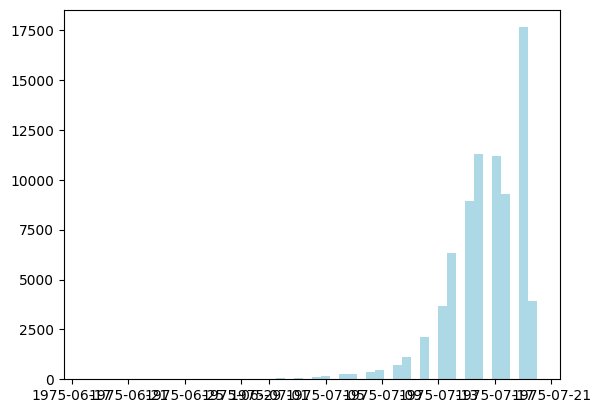

In [181]:
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# generate some random data (approximately over 5 years)
data = [float(random.randint(1271517521, 1429197513)) for _ in range(1000)]

# convert the epoch format to matplotlib date format 
mpl_data = dates

# plot it
fig, ax = plt.subplots(1,1)
ax.hist(mpl_data, bins=50, color='lightblue')
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


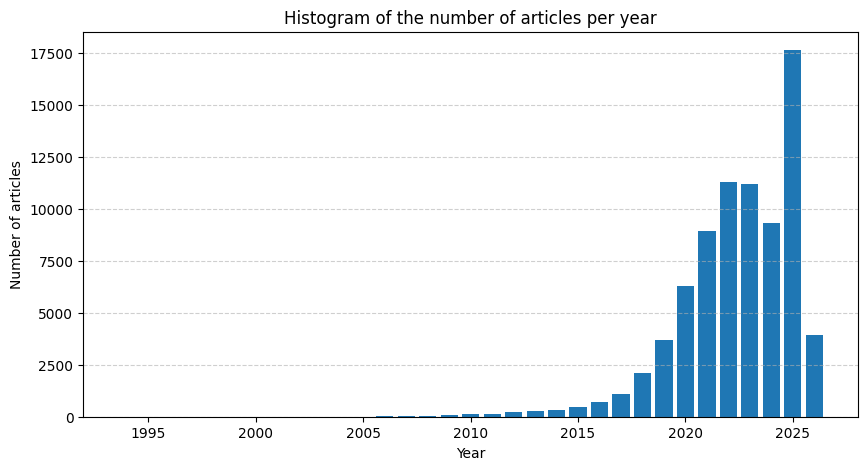

In [184]:

import matplotlib.pyplot as plt
from collections import Counter

# przykładowe dane
# dates = [2020, 2021, 2020, 2023, 2023, 2023]

# zlicz lata
counter = Counter(dates)

# sortowanie lat rosnąco
years = sorted(counter.keys())
counts = [counter[y] for y in years]

# rysowanie histogramu (w formie słupków)
plt.figure(figsize=(10, 5))
plt.bar(years, counts)

plt.xlabel("Year")
plt.ylabel("Number of articles")
plt.title("Histogram of the number of articles per year")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('plots/papershistogram.eps', format='eps')
plt.show()
